# PROYECTO ULAB — Fase 1: Análisis Exploratorio de Datos
**Predicción de Histogramas de Carga de Trabajo en Proyectos Industriales**  
Colaboración UAX × Técnicas Reunidas

---
### Estructura del notebook
1. Carga y descripción de los datos  
2. Análisis de muestras: totales, por proyecto, por departamento  
3. Missing values  
4. Outliers  
5. Análisis temporal y periodicidad (espectral + STL)  
6. Preprocesamiento y dataset agregado semanal  
7. Ingeniería de características (codificación temporal lineal y cíclica)  
8. Conclusiones
---

## 0. Importaciones y configuración

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.signal import periodogram
from statsmodels.tsa.seasonal import STL
import warnings
warnings.filterwarnings('ignore')

# Estilo global
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

# Paleta de casos
COLORES_CASO = {1: '#2196F3', 2: '#FF9800', 3: '#4CAF50', 4: '#E91E63'}

print(' Librerías cargadas correctamente')

 Librerías cargadas correctamente


## 1. Carga de datos

El dataset proviene de **Técnicas Reunidas** y contiene registros diarios de horas trabajadas (ACTUAL) y planificadas (INICIAL) por persona, departamento y proyecto (caso).

In [39]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/ULAB'
DATA_PATH = f'{BASE_PATH}/data'
MODELOS_PATH = f'{BASE_PATH}/modelos'
RESULTADOS_PATH = f'{BASE_PATH}/resultados'
NOTEBOOKS_PATH = f'{BASE_PATH}/notebooks'

RUTA_ACTUAL = f'{DATA_PATH}/ACTUAL.csv'
RUTA_INI    = f'{DATA_PATH}/INI.csv'
RUTA_CASO   = f'{DATA_PATH}/CASO.csv'
RUTA_DEPT   = f'{DATA_PATH}/DEPT.csv'

df_act  = pd.read_csv(RUTA_ACTUAL, sep=';', decimal=',', encoding='utf-8-sig')
df_ini  = pd.read_csv(RUTA_INI,    sep=';', decimal=',', encoding='utf-8-sig')
df_caso = pd.read_csv(RUTA_CASO,   sep=';', decimal=',', encoding='utf-8-sig')
df_dept = pd.read_csv(RUTA_DEPT,   sep=';',              encoding='utf-8-sig')

df_act['DIA'] = pd.to_datetime(df_act['DIA'], dayfirst=True, errors='coerce')
df_ini['DIA'] = pd.to_datetime(df_ini['DIA'], dayfirst=True, errors='coerce')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Análisis de muestras

### 2.1 Número total de muestras

In [40]:
print('='*55)
print(f'  Registros en ACTUAL  (horas reales)    : {len(df_act):>8,}')
print(f'  Registros en INICIAL (horas planif.)   : {len(df_ini):>8,}')
print(f'  Proyectos (casos)                      : {df_act["Caso"].nunique():>8}')
print(f'  Departamentos únicos en ACTUAL         : {df_act["Departamento"].nunique():>8}')
print(f'  Departamentos en catálogo DEPT         : {df_dept["Departamento"].nunique():>8}')
print(f'  Rango fechas ACTUAL  : {df_act["DIA"].min().date()} → {df_act["DIA"].max().date()}')
print(f'  Rango fechas INICIAL : {df_ini["DIA"].min().date()} → {df_ini["DIA"].max().date()}')
print('='*55)

  Registros en ACTUAL  (horas reales)    :  265,497
  Registros en INICIAL (horas planif.)   :   15,041
  Proyectos (casos)                      :        4
  Departamentos únicos en ACTUAL         :       52
  Departamentos en catálogo DEPT         :       53
  Rango fechas ACTUAL  : 2015-11-03 → 2019-11-03
  Rango fechas INICIAL : 2015-03-14 → 2020-12-31


### 2.2 Muestras por proyecto (caso)

,Caso,Registros,HR_Total,HR_Media,Fecha_Ini,Fecha_Fin,Depts,Duración_días,País,Finalizado
0,1,65648,109729.75,1.67,2016-05-05,2019-11-01,38,1275,TURKEY,SI
1,2,141546,263864.00,1.86,2017-01-03,2019-11-03,39,1034,QATAR,NO
2,3,46196,92532.80,2.00,2015-11-03,2019-10-19,23,1446,COLOMBIA,SI
3,4,12107,20239.70,1.67,2017-05-02,2019-10-19,12,900,ARGENTINA,NO


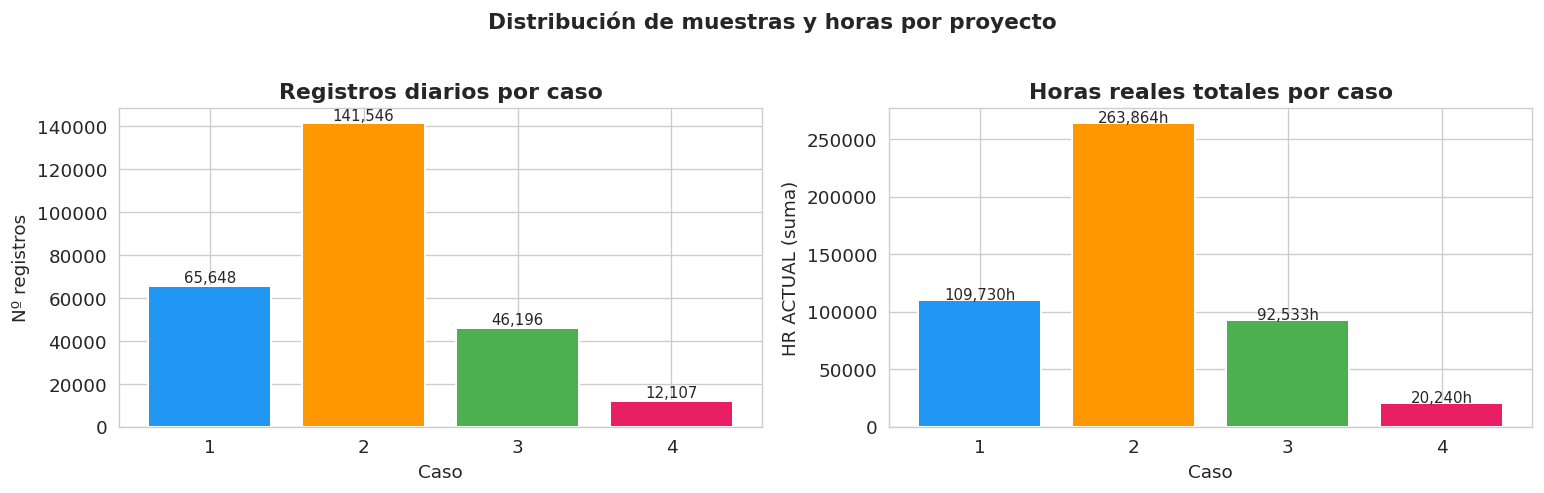

 El análisis predictivo se centrará en los casos 1 y 3 (proyectos FINALIZADOS).


In [41]:
muestras_caso = df_act.groupby('Caso').agg(
    Registros   = ('HR ACTUAL', 'count'),
    HR_Total    = ('HR ACTUAL', 'sum'),
    HR_Media    = ('HR ACTUAL', 'mean'),
    Fecha_Ini   = ('DIA', 'min'),
    Fecha_Fin   = ('DIA', 'max'),
    Depts       = ('Departamento', 'nunique')
).reset_index()
muestras_caso['Duración_días'] = (muestras_caso['Fecha_Fin'] - muestras_caso['Fecha_Ini']).dt.days

# Añadir info de CASO
df_caso_aux = df_caso.rename(columns={'CASO':'Caso','FINALIZADO':'Finalizado','COUNTRY':'País'})[['Caso','País','Finalizado']]
muestras_caso = muestras_caso.merge(df_caso_aux, on='Caso')

display(muestras_caso.round(2))

# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colores = [COLORES_CASO[c] for c in muestras_caso['Caso']]
axes[0].bar(muestras_caso['Caso'].astype(str), muestras_caso['Registros'], color=colores, edgecolor='white', linewidth=1.2)
axes[0].set_title('Registros diarios por caso', fontweight='bold')
axes[0].set_xlabel('Caso'); axes[0].set_ylabel('Nº registros')
for bar, v in zip(axes[0].patches, muestras_caso['Registros']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1500, f'{v:,}', ha='center', fontsize=9)

axes[1].bar(muestras_caso['Caso'].astype(str), muestras_caso['HR_Total'], color=colores, edgecolor='white', linewidth=1.2)
axes[1].set_title('Horas reales totales por caso', fontweight='bold')
axes[1].set_xlabel('Caso'); axes[1].set_ylabel('HR ACTUAL (suma)')
for bar, v in zip(axes[1].patches, muestras_caso['HR_Total']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000, f'{v:,.0f}h', ha='center', fontsize=9)

plt.suptitle('Distribución de muestras y horas por proyecto', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(' El análisis predictivo se centrará en los casos 1 y 3 (proyectos FINALIZADOS).')

### 2.3 Muestras por departamento

In [42]:
# Merge con nombres de departamento
df_act_named = df_act.merge(df_dept, on='Departamento', how='left')

# Función reutilizable para análisis por dept
def resumen_dept(df, titulo='Todas las muestras'):
    res = df.groupby(['Departamento','Descripción']).agg(
        Registros = ('HR ACTUAL','count'),
        HR_Total  = ('HR ACTUAL','sum'),
        HR_Media  = ('HR ACTUAL','mean')
    ).reset_index().sort_values('Registros', ascending=False)
    print(f'\n--- {titulo} --- ({len(res)} departamentos con datos)')
    display(res.head(10).round(2))
    return res

res_total = resumen_dept(df_act_named, 'Todas las muestras')
res_c1    = resumen_dept(df_act_named[df_act_named['Caso']==1], 'Caso 1 (Turquía - Finalizado)')
res_c3    = resumen_dept(df_act_named[df_act_named['Caso']==3], 'Caso 3 (Colombia - Finalizado)')
res_c13   = resumen_dept(df_act_named[df_act_named['Caso'].isin([1,3])], 'Casos 1+3 combinados')


--- Todas las muestras --- (51 departamentos con datos)


,Departamento,Descripción,Registros,HR_Total,HR_Media
32,760.0,Supervisión Construcción,62494,115721.55,1.85
15,475.0,HSE Construcción,41543,74025.30,1.78
12,455.0,HSE y Medioambiente,31595,61815.20,1.96
11,450.0,CALIDAD,17721,33556.60,1.89
14,470.0,QC,16953,29668.00,1.75
35,780.0,Gestión de Materiales,12624,23246.30,1.84
36,805.0,Comisionado,12611,22950.50,1.82
34,775.0,Admon. Subcontratos,8677,16096.30,1.86
5,205.0,RR.HH. Y Servicios Generales,5419,10179.10,1.88
33,765.0,Control de Producción,5352,9444.40,1.76



--- Caso 1 (Turquía - Finalizado) --- (38 departamentos con datos)


,Departamento,Descripción,Registros,HR_Total,HR_Media
23,760.0,Supervisión Construcción,17246,28547.55,1.66
27,805.0,Comisionado,6781,11274.70,1.66
11,475.0,HSE Construcción,4148,6952.40,1.68
9,455.0,HSE y Medioambiente,3955,6583.00,1.66
24,765.0,Control de Producción,3779,6298.40,1.67
26,780.0,Gestión de Materiales,3620,6040.10,1.67
28,810.0,Hand Over,3606,5994.50,1.66
8,450.0,CALIDAD,3440,5741.80,1.67
10,470.0,QC,3392,5662.80,1.67
3,205.0,RR.HH. Y Servicios Generales,2456,4408.70,1.80



--- Caso 3 (Colombia - Finalizado) --- (23 departamentos con datos)


,Departamento,Descripción,Registros,HR_Total,HR_Media
15,760.0,Supervisión Construcción,10298,20596.0,2.00
6,450.0,CALIDAD,7258,14516.0,2.00
7,455.0,HSE y Medioambiente,6411,12822.0,2.00
19,805.0,Comisionado,5709,11457.8,2.01
18,780.0,Gestión de Materiales,5633,11266.0,2.00
17,775.0,Admon. Subcontratos,2350,4718.0,2.01
3,205.0,RR.HH. Y Servicios Generales,1762,3524.0,2.00
16,765.0,Control de Producción,1573,3146.0,2.00
10,685.0,Instrumentación y Control,1160,2398.0,2.07
5,410.0,Control de Documentación,865,1730.0,2.00



--- Casos 1+3 combinados --- (42 departamentos con datos)


,Departamento,Descripción,Registros,HR_Total,HR_Media
27,760.0,Supervisión Construcción,27544,49143.55,1.78
31,805.0,Comisionado,12490,22732.50,1.82
10,450.0,CALIDAD,10698,20257.80,1.89
11,455.0,HSE y Medioambiente,10366,19405.00,1.87
30,780.0,Gestión de Materiales,9253,17306.10,1.87
28,765.0,Control de Producción,5352,9444.40,1.76
32,810.0,Hand Over,4226,7234.50,1.71
5,205.0,RR.HH. Y Servicios Generales,4218,7932.70,1.88
13,475.0,HSE Construcción,4148,6952.40,1.68
29,775.0,Admon. Subcontratos,3531,6683.50,1.89


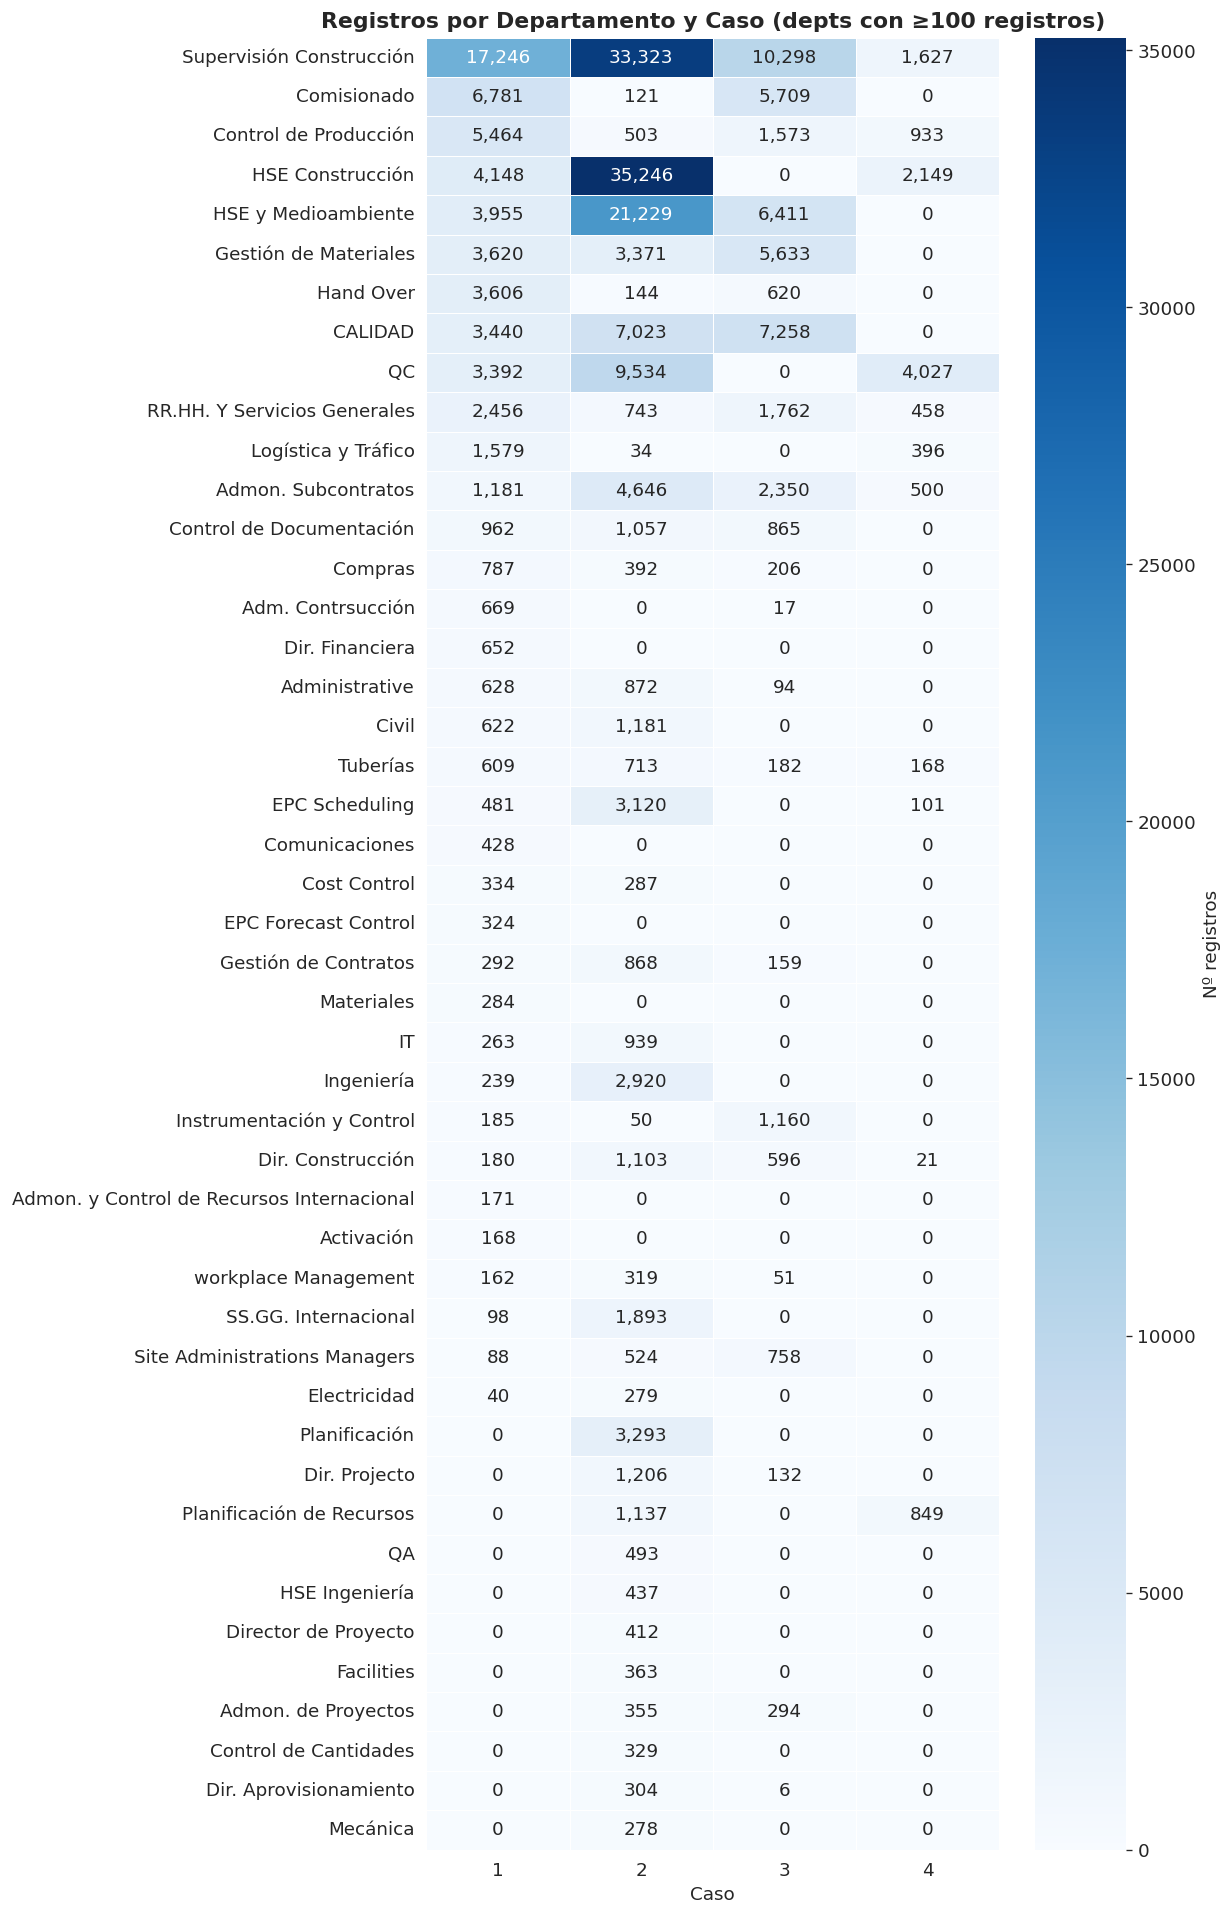

In [43]:
# Heatmap de registros: Departamento × Caso
pivot_dept_caso = df_act_named.groupby(['Descripción','Caso'])['HR ACTUAL'].count().unstack(fill_value=0)
# Filtrar depts con al menos 100 registros en algún caso
pivot_dept_caso = pivot_dept_caso[pivot_dept_caso.max(axis=1) >= 100].sort_values(by=pivot_dept_caso.columns.tolist(), ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_dept_caso)*0.35)))
sns.heatmap(pivot_dept_caso, annot=True, fmt=',d', cmap='Blues', linewidths=0.5, ax=ax,
            cbar_kws={'label':'Nº registros'})
ax.set_title('Registros por Departamento y Caso (depts con ≥100 registros)', fontweight='bold')
ax.set_xlabel('Caso'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 3. Missing Values

In [44]:
def analisis_missings(df, nombre):
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    resumen = pd.DataFrame({'Missings': miss, '%': miss_pct})
    resumen = resumen[resumen['Missings'] > 0]
    print(f'\n=== Missing values: {nombre} ({len(df):,} registros) ===')
    if resumen.empty:
        print('  Sin valores nulos')
    else:
        display(resumen)
    return resumen

m_act  = analisis_missings(df_act,  'ACTUAL')
m_ini  = analisis_missings(df_ini,  'INICIAL')
m_caso = analisis_missings(df_caso, 'CASO')
m_dept = analisis_missings(df_dept, 'DEPT')


=== Missing values: ACTUAL (265,497 registros) ===


,Missings,%
Departamento,510,0.19



=== Missing values: INICIAL (15,041 registros) ===


,Missings,%
Persona,7674,51.02
Receptor,15041,100.00



=== Missing values: CASO (4 registros) ===
  Sin valores nulos

=== Missing values: DEPT (53 registros) ===
  Sin valores nulos


In [45]:
# Análisis espacial de missings en ACTUAL (Departamento nulo)
missing_dept = df_act[df_act['Departamento'].isnull()]
print(f'Registros con Departamento nulo en ACTUAL: {len(missing_dept):,}')
print(f'  → Por caso: {missing_dept["Caso"].value_counts().to_dict()}')
print(f'  → Rango fechas: {missing_dept["DIA"].min().date()} a {missing_dept["DIA"].max().date()}')
print(f'  → HR ACTUAL en esos registros: media={missing_dept["HR ACTUAL"].mean():.2f}, total={missing_dept["HR ACTUAL"].sum():.0f}h')
print('\nDecisión: estos registros se EXCLUIRÁN del análisis al no poder asignarse a ningún departamento.')

# Análisis de missings en INICIAL (Persona, Receptor)
print(f'\nINICIAL — Persona nula: {df_ini["Persona"].isnull().sum():,} ({100*df_ini["Persona"].isnull().mean():.1f}%)')
print(f'INICIAL — Receptor nulo: {df_ini["Receptor"].isnull().sum():,} ({100*df_ini["Receptor"].isnull().mean():.1f}%)')
print('\nDecisión: Persona y Receptor no se usan como features → no afectan al modelo.')

Registros con Departamento nulo en ACTUAL: 510
  → Por caso: {2: 505, 4: 5}
  → Rango fechas: 2017-04-30 a 2019-10-31
  → HR ACTUAL en esos registros: media=2.87, total=1465h

Decisión: estos registros se EXCLUIRÁN del análisis al no poder asignarse a ningún departamento.

INICIAL — Persona nula: 7,674 (51.0%)
INICIAL — Receptor nulo: 15,041 (100.0%)

Decisión: Persona y Receptor no se usan como features → no afectan al modelo.


## 4. Outliers

In [46]:
# Análisis de outliers en HR ACTUAL (nivel registro diario)
hr = df_act['HR ACTUAL']

Q1, Q3 = hr.quantile(0.25), hr.quantile(0.75)
IQR = Q3 - Q1
lb_iqr = Q1 - 1.5*IQR
ub_iqr = Q3 + 1.5*IQR
n_iqr = ((hr < lb_iqr) | (hr > ub_iqr)).sum()

z_scores = np.abs(stats.zscore(hr))
n_z3 = (z_scores > 3).sum()

p1, p99 = hr.quantile(0.01), hr.quantile(0.99)
n_p = ((hr < p1) | (hr > p99)).sum()

print('=== Detección de outliers en HR ACTUAL (registro diario) ===')
print(f'  Rango válido IQR  [{lb_iqr:.2f}, {ub_iqr:.2f}] → {n_iqr:,} outliers ({100*n_iqr/len(hr):.2f}%)')
print(f'  |Z-score| > 3                            → {n_z3:,} outliers ({100*n_z3/len(hr):.2f}%)')
print(f'  Percentil [1%, 99%]  [{p1:.2f}, {p99:.2f}]  → {n_p:,} outliers ({100*n_p/len(hr):.2f}%)')
print(f'\n  Valor mínimo: {hr.min():.2f}h   Valor máximo: {hr.max():.2f}h')
print(f'  Percentil 99.9%: {hr.quantile(0.999):.2f}h')

=== Detección de outliers en HR ACTUAL (registro diario) ===
  Rango válido IQR  [1.50, 2.30] → 38,605 outliers (14.54%)
  |Z-score| > 3                            → 1,270 outliers (0.48%)
  Percentil [1%, 99%]  [0.40, 2.40]  → 1,792 outliers (0.67%)

  Valor mínimo: 0.20h   Valor máximo: 46.00h
  Percentil 99.9%: 4.00h


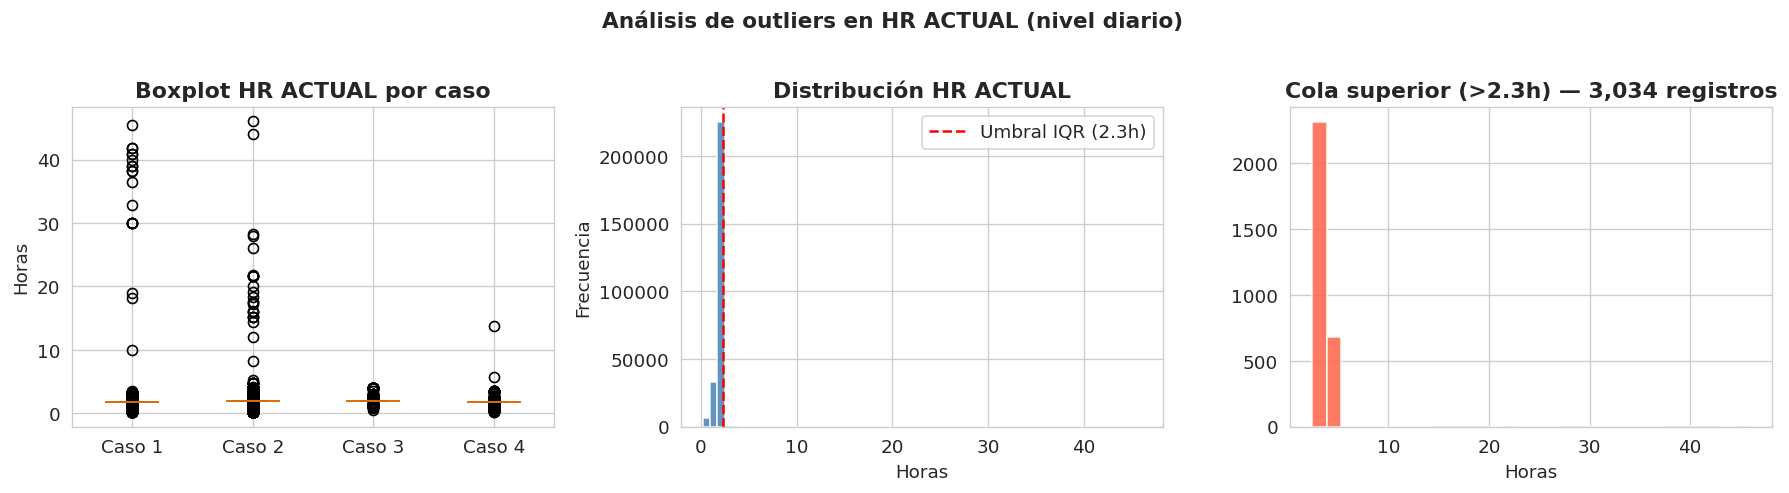


Conclusión: el rango habitual es [0.2, 3.5]h por registro diario.
Valores > 10h por persona/día son probablemente errores o imputaciones bulk.


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Boxplot por caso
data_casos = [df_act[df_act['Caso']==c]['HR ACTUAL'].values for c in [1,2,3,4]]
bp = axes[0].boxplot(data_casos, patch_artist=True, labels=['Caso 1','Caso 2','Caso 3','Caso 4'])
for patch, c in zip(bp['boxes'], [1,2,3,4]):
    patch.set_facecolor(COLORES_CASO[c])
axes[0].set_title('Boxplot HR ACTUAL por caso', fontweight='bold')
axes[0].set_ylabel('Horas')

# Histograma general
axes[1].hist(hr, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(ub_iqr, color='red', linestyle='--', label=f'Umbral IQR ({ub_iqr:.1f}h)')
axes[1].set_title('Distribución HR ACTUAL', fontweight='bold')
axes[1].set_xlabel('Horas'); axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# Zoom en la cola superior (outliers)
outliers_sup = hr[hr > ub_iqr]
axes[2].hist(outliers_sup, bins=30, color='tomato', edgecolor='white', alpha=0.85)
axes[2].set_title(f'Cola superior (>{ub_iqr:.1f}h) — {len(outliers_sup):,} registros', fontweight='bold')
axes[2].set_xlabel('Horas')

plt.suptitle('Análisis de outliers en HR ACTUAL (nivel diario)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nConclusión: el rango habitual es [0.2, 3.5]h por registro diario.')
print('Valores > 10h por persona/día son probablemente errores o imputaciones bulk.')

In [48]:
# Outliers a nivel semanal agregado (que es el nivel de modelado)
df_act_clean = df_act.dropna(subset=['Departamento']).copy()
df_act_clean['Semana'] = df_act_clean['DIA'].dt.to_period('W')

agg_sem = df_act_clean.groupby(['Caso','Departamento','Semana'])['HR ACTUAL'].sum().reset_index()
agg_sem.rename(columns={'HR ACTUAL':'HR_ACTUAL_SEM'}, inplace=True)

hr_sem = agg_sem['HR_ACTUAL_SEM']
Q1s, Q3s = hr_sem.quantile(0.25), hr_sem.quantile(0.75)
IQRs = Q3s - Q1s
n_out_sem = ((hr_sem < Q1s-1.5*IQRs) | (hr_sem > Q3s+1.5*IQRs)).sum()

print('=== Outliers en HR ACTUAL agregada SEMANAL por (Caso, Dpto) ===')
print(f'  Total muestras semanales: {len(hr_sem):,}')
print(f'  Rango IQR: [{Q1s-1.5*IQRs:.1f}, {Q3s+1.5*IQRs:.1f}]h/semana')
print(f'  Outliers detectados: {n_out_sem:,} ({100*n_out_sem/len(hr_sem):.2f}%)')
print(f'  Media: {hr_sem.mean():.1f}h  |  Mediana: {hr_sem.median():.1f}h  |  Máx: {hr_sem.max():.1f}h')

=== Outliers en HR ACTUAL agregada SEMANAL por (Caso, Dpto) ===
  Total muestras semanales: 8,912
  Rango IQR: [-47.0, 105.0]h/semana
  Outliers detectados: 1,108 (12.43%)
  Media: 54.4h  |  Mediana: 19.2h  |  Máx: 979.8h


## 5. Análisis temporal y periodicidades

El cronograma indica analizar las periodicidades mediante:
- **Análisis espectral** (periodograma)
- **Descomposición STL** (Seasonal and Trend decomposition using Loess)

Se analizará la **serie temporal agregada semanal** de HR ACTUAL para los casos 1 y 3.

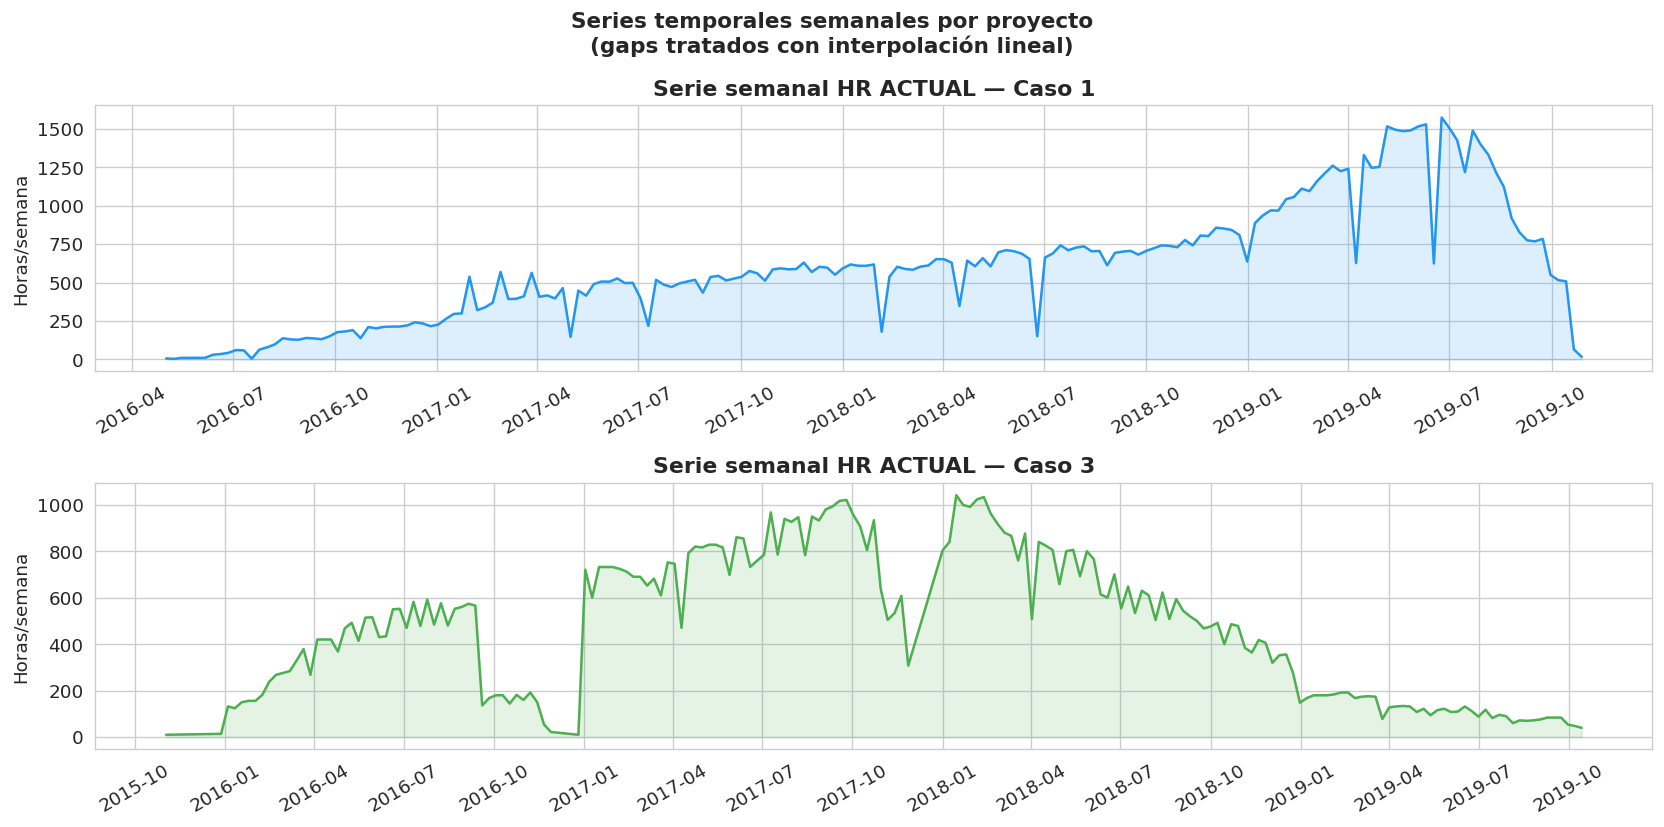

In [49]:
def serie_semanal_caso(df_clean, caso, metodo_gaps='interp'):
    sub = df_clean[df_clean['Caso'] == caso].copy()

    if sub.empty:
        return pd.Series(dtype=float)

    # Alinear cada fecha al lunes de su semana
    sub['Semana_inicio'] = sub['DIA'] - pd.to_timedelta(sub['DIA'].dt.weekday, unit='d')

    # Agregación semanal
    serie = sub.groupby('Semana_inicio')['HR ACTUAL'].sum().sort_index()

    # Índice semanal continuo
    idx_completo = pd.date_range(serie.index.min(), serie.index.max(), freq='W-MON')
    serie = serie.reindex(idx_completo)

    # Tratamiento de gaps
    if metodo_gaps == 'interp':
        serie = serie.interpolate(method='linear', limit_direction='both')
    elif metodo_gaps == 'zero':
        serie = serie.fillna(0)
    else:
        raise ValueError("metodo_gaps debe ser 'interp' o 'zero'")

    # Evitar posibles valores negativos por artefactos
    serie = serie.clip(lower=0)

    return serie


# Series semanales de los casos 1 y 3
serie_c1 = serie_semanal_caso(df_act_clean, 1, metodo_gaps='interp')
serie_c3 = serie_semanal_caso(df_act_clean, 3, metodo_gaps='interp')

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, serie, caso, color in zip(
    axes,
    [serie_c1, serie_c3],
    [1, 3],
    ['#2196F3', '#4CAF50']
):
    ax.plot(serie.index, serie.values, color=color, linewidth=1.5)
    ax.fill_between(serie.index, serie.values, alpha=0.15, color=color)

    ax.set_title(f'Serie semanal HR ACTUAL — Caso {caso}', fontweight='bold')
    ax.set_ylabel('Horas/semana')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle(
    'Series temporales semanales por proyecto\n(gaps tratados con interpolación lineal)',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

### 5.1 Análisis espectral (periodograma)

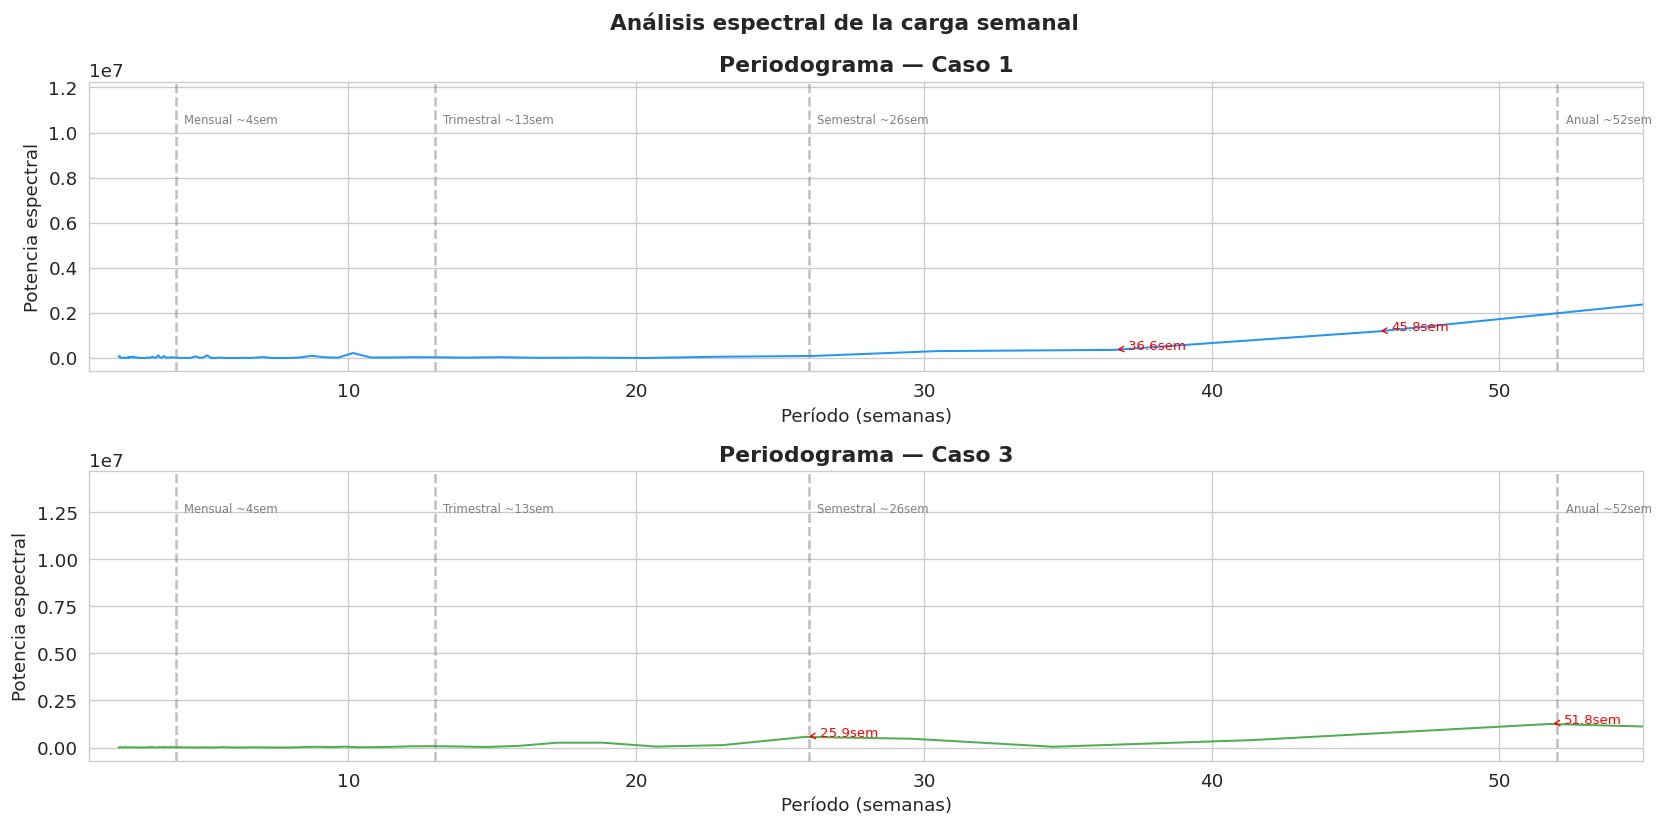

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for ax, serie, caso, color in zip(axes, [serie_c1, serie_c3], [1, 3], ['#2196F3','#4CAF50']):
    freqs, potencia = periodogram(serie.values, fs=1.0)  # fs=1 semana
    # Evitar freq=0
    freqs, potencia = freqs[1:], potencia[1:]
    periodos = 1.0 / freqs  # en semanas

    ax.plot(periodos, potencia, color=color, linewidth=1.2)
    ax.set_xlim(1, 55)
    ax.set_xlabel('Período (semanas)')
    ax.set_ylabel('Potencia espectral')
    ax.set_title(f'Periodograma — Caso {caso}', fontweight='bold')

    # Marcar los 3 picos más importantes
    idx_top = np.argsort(potencia)[-5:]
    for idx in idx_top:
        ax.annotate(f'{periodos[idx]:.1f}sem', xy=(periodos[idx], potencia[idx]),
                    xytext=(periodos[idx]+0.5, potencia[idx]*1.02),
                    fontsize=8, color='red', arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

    # Líneas de referencia
    for p, lbl in [(4,'Mensual ~4sem'), (13,'Trimestral ~13sem'), (26,'Semestral ~26sem'), (52,'Anual ~52sem')]:
        ax.axvline(p, color='gray', linestyle='--', alpha=0.5)
        ax.text(p+0.3, ax.get_ylim()[1]*0.85, lbl, fontsize=7, color='gray')

plt.suptitle('Análisis espectral de la carga semanal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Descomposición STL

=== Caso 1 ===


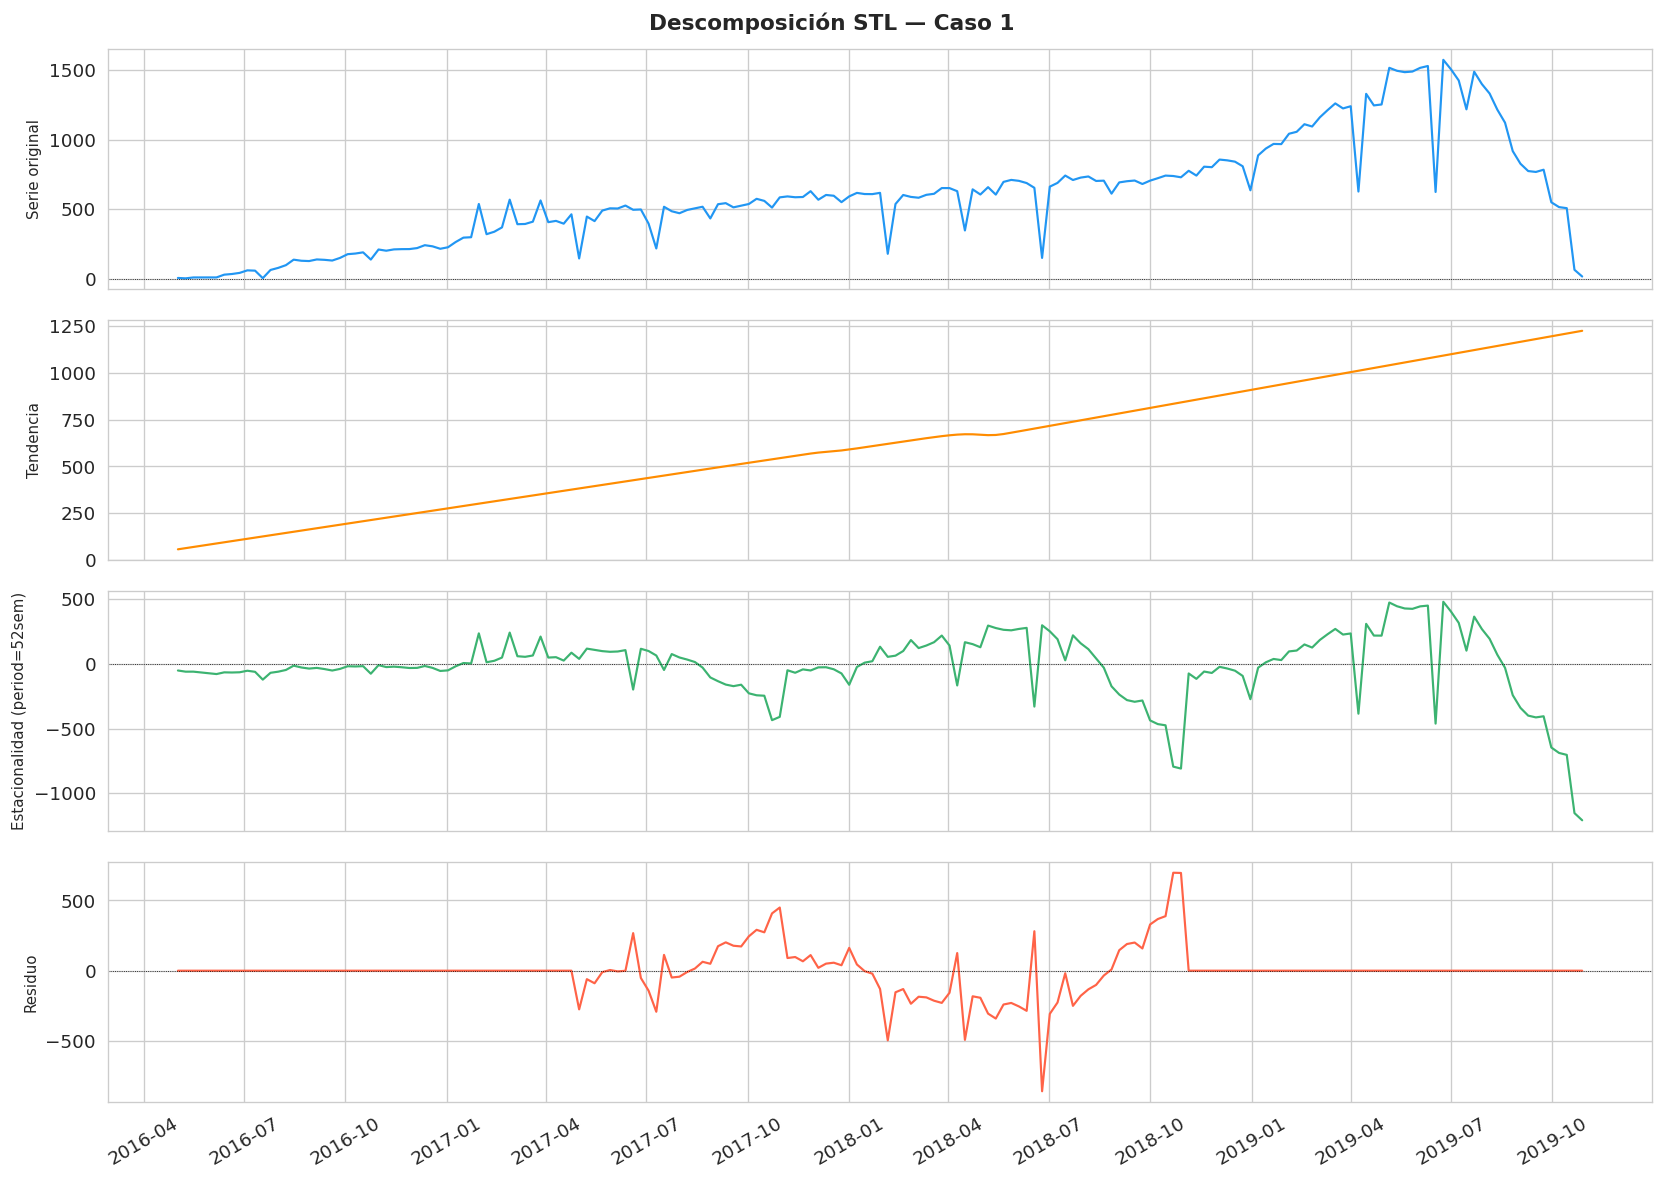

Caso 1 — Fuerza Estacional: 0.442  |  Fuerza Tendencial: 0.801
=== Caso 3 ===


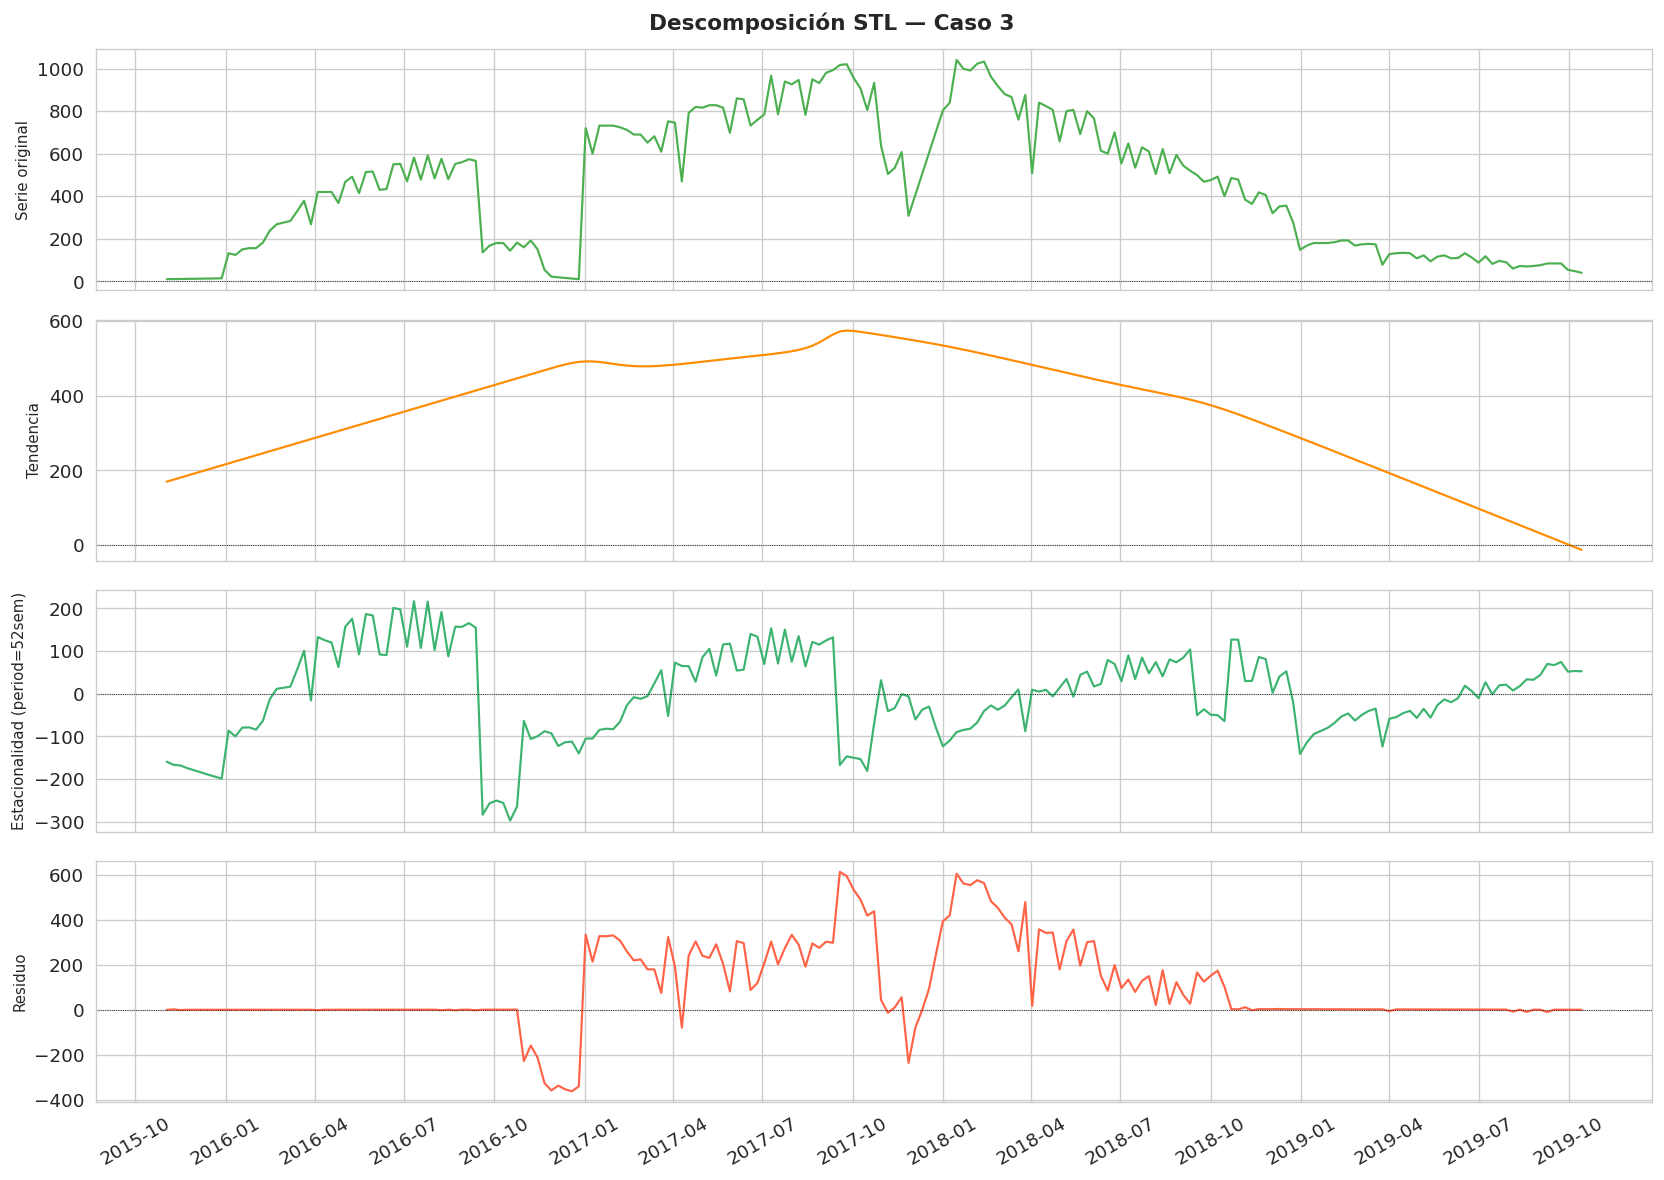

Caso 3 — Fuerza Estacional: 0.226  |  Fuerza Tendencial: 0.596


In [51]:
def plot_stl(serie, caso, periodo=52, color='steelblue'):
    # STL requiere al menos 2 ciclos completos. Periodo=52 semanas (anual).
    # Si la serie es corta usamos periodo=13 (trimestral)
    if len(serie) < 2*periodo:
        periodo = 13
    stl = STL(serie, period=periodo, robust=True)
    resultado = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    componentes = [
        (serie.values,           'Serie original',  color),
        (resultado.trend,        'Tendencia',        'darkorange'),
        (resultado.seasonal,     f'Estacionalidad (period={periodo}sem)', 'mediumseagreen'),
        (resultado.resid,        'Residuo',          'tomato'),
    ]
    for ax, (datos, titulo, col) in zip(axes, componentes):
        ax.plot(serie.index, datos, color=col, linewidth=1.3)
        ax.set_ylabel(titulo, fontsize=9)
        ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
    fig.suptitle(f'Descomposición STL — Caso {caso}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Fuerza estacional y tendencial
    var_resid = np.var(resultado.resid)
    Fs = max(0, 1 - var_resid / np.var(resultado.seasonal + resultado.resid))
    Ft = max(0, 1 - var_resid / np.var(resultado.trend   + resultado.resid))
    print(f'Caso {caso} — Fuerza Estacional: {Fs:.3f}  |  Fuerza Tendencial: {Ft:.3f}')
    return resultado

print('=== Caso 1 ===')
stl_c1 = plot_stl(serie_c1, caso=1, color='#2196F3')
print('=== Caso 3 ===')
stl_c3 = plot_stl(serie_c3, caso=3, color='#4CAF50')

## 6. Preprocesamiento y dataset agregado semanal

Preparamos el dataset final para modelado (nivel: semana × departamento × caso).

In [52]:
# --- 6.1 Limpieza base ---
df_clean = df_act.dropna(subset=['Departamento']).copy()
df_clean['Departamento'] = df_clean['Departamento'].astype(int)

# Alineamos la fecha al inicio de semana (lunes)
df_clean['Semana_inicio'] = df_clean['DIA'] - pd.to_timedelta(df_clean['DIA'].dt.weekday, unit='d')

# --- 6.2 Agregación semanal por (Caso, Departamento, Semana) ---
df_agg = df_clean.groupby(['Caso','Departamento','Semana_inicio']).agg(
    HR_ACTUAL = ('HR ACTUAL', 'sum')
).reset_index().sort_values(['Caso','Departamento','Semana_inicio'])

print(f'Dataset semanal: {df_agg.shape[0]:,} filas × {df_agg.shape[1]} columnas')
display(df_agg.head(8))

Dataset semanal: 8,912 filas × 4 columnas


,Caso,Departamento,Semana_inicio,HR_ACTUAL
0,1,100,2017-07-10,1.0
1,1,100,2017-07-17,10.0
2,1,100,2017-07-24,10.0
3,1,100,2017-07-31,10.0
4,1,100,2017-08-07,10.0
5,1,100,2017-08-14,6.4
6,1,100,2017-08-21,2.8
7,1,100,2017-08-28,8.2


In [53]:
# --- 6.3 Incorporar HR INICIAL (horas planificadas) ---
df_ini_clean = df_ini.copy()
df_ini_clean['Semana_inicio'] = df_ini_clean['DIA'] - pd.to_timedelta(df_ini_clean['DIA'].dt.weekday, unit='d')

df_ini_agg = df_ini_clean.groupby(['Caso','Departamento','Semana_inicio']).agg(
    HR_INICIAL = ('HR INICIAL', 'sum')
).reset_index()

df_model = df_agg.merge(df_ini_agg, on=['Caso','Departamento','Semana_inicio'], how='left')
df_model['HR_INICIAL'] = df_model['HR_INICIAL'].fillna(0)

print(f'Dataset con HR_INICIAL: {df_model.shape}')
print(f'% semanas con HR_INICIAL > 0: {(df_model["HR_INICIAL"]>0).mean()*100:.1f}%')

Dataset con HR_INICIAL: (8912, 5)
% semanas con HR_INICIAL > 0: 21.5%


## 7. Ingeniería de características

Según el cronograma, se estudiarán esquemas de codificación **lineal** y **cíclico** (sin/cos) para las variables temporales.

In [54]:
df_feat = df_model.copy()

# --- Variables temporales base ---
df_feat['Año']           = df_feat['Semana_inicio'].dt.year
df_feat['Mes']           = df_feat['Semana_inicio'].dt.month          # 1-12 (lineal)
df_feat['Semana_año']    = df_feat['Semana_inicio'].dt.isocalendar().week.astype(int)  # 1-52 (lineal)
df_feat['Dia_semana']    = df_feat['Semana_inicio'].dt.weekday + 1    # 1=Lun … 5=Vie (lineal)

# --- Codificación cíclica (sin/cos) ---
df_feat['Mes_sin']       = np.sin(2 * np.pi * df_feat['Mes']       / 12)
df_feat['Mes_cos']       = np.cos(2 * np.pi * df_feat['Mes']       / 12)
df_feat['Semana_sin']    = np.sin(2 * np.pi * df_feat['Semana_año'] / 52)
df_feat['Semana_cos']    = np.cos(2 * np.pi * df_feat['Semana_año'] / 52)
df_feat['Dia_sin']       = np.sin(2 * np.pi * df_feat['Dia_semana'] / 5)
df_feat['Dia_cos']       = np.cos(2 * np.pi * df_feat['Dia_semana'] / 5)

# --- Variables de contexto temporal del proyecto ---
fecha_inicio_proyecto = df_feat.groupby('Caso')['Semana_inicio'].transform('min')
fecha_fin_proyecto    = df_feat.groupby('Caso')['Semana_inicio'].transform('max')
df_feat['Dias_desde_inicio'] = (df_feat['Semana_inicio'] - fecha_inicio_proyecto).dt.days
df_feat['Dias_hasta_fin']    = (fecha_fin_proyecto - df_feat['Semana_inicio']).dt.days
df_feat['Dias_hasta_fin_año']= (pd.to_datetime(df_feat['Año'].astype(str)+'-12-31') - df_feat['Semana_inicio']).dt.days

# --- Lag autoregresivo (HR_ACTUAL t-1) ---
df_feat = df_feat.sort_values(['Caso','Departamento','Semana_inicio'])
df_feat['HR_ACTUAL_t1'] = df_feat.groupby(['Caso','Departamento'])['HR_ACTUAL'].shift(1)
df_feat['HR_ACTUAL_t2'] = df_feat.groupby(['Caso','Departamento'])['HR_ACTUAL'].shift(2)
df_feat['HR_ACTUAL_t4'] = df_feat.groupby(['Caso','Departamento'])['HR_ACTUAL'].shift(4)

# --- Ratio real/planificado del periodo anterior ---
df_feat['HR_INI_t1']    = df_feat.groupby(['Caso','Departamento'])['HR_INICIAL'].shift(1)
df_feat['Ratio_ini_t1'] = np.where(df_feat['HR_INI_t1'] > 0,
                                    df_feat['HR_ACTUAL_t1'] / df_feat['HR_INI_t1'], np.nan)

print(f'Dataset con features: {df_feat.shape}')
print('\nColumnas generadas:')
print(df_feat.columns.tolist())
display(df_feat.head(5))

Dataset con features: (8912, 23)

Columnas generadas:
['Caso', 'Departamento', 'Semana_inicio', 'HR_ACTUAL', 'HR_INICIAL', 'Año', 'Mes', 'Semana_año', 'Dia_semana', 'Mes_sin', 'Mes_cos', 'Semana_sin', 'Semana_cos', 'Dia_sin', 'Dia_cos', 'Dias_desde_inicio', 'Dias_hasta_fin', 'Dias_hasta_fin_año', 'HR_ACTUAL_t1', 'HR_ACTUAL_t2', 'HR_ACTUAL_t4', 'HR_INI_t1', 'Ratio_ini_t1']


,Caso,Departamento,Semana_inicio,HR_ACTUAL,HR_INICIAL,Año,Mes,Semana_año,Dia_semana,Mes_sin,...,Dia_sin,Dia_cos,Dias_desde_inicio,Dias_hasta_fin,Dias_hasta_fin_año,HR_ACTUAL_t1,HR_ACTUAL_t2,HR_ACTUAL_t4,HR_INI_t1,Ratio_ini_t1
0,1,100,2017-07-10,1.0,0.0,2017,7,28,1,-0.500000,...,0.951057,0.309017,434,840,174,NaN,NaN,NaN,NaN,NaN
1,1,100,2017-07-17,10.0,0.0,2017,7,29,1,-0.500000,...,0.951057,0.309017,441,833,167,1.0,NaN,NaN,0.0,NaN
2,1,100,2017-07-24,10.0,0.0,2017,7,30,1,-0.500000,...,0.951057,0.309017,448,826,160,10.0,1.0,NaN,0.0,NaN
3,1,100,2017-07-31,10.0,0.0,2017,7,31,1,-0.500000,...,0.951057,0.309017,455,819,153,10.0,10.0,NaN,0.0,NaN
4,1,100,2017-08-07,10.0,0.0,2017,8,32,1,-0.866025,...,0.951057,0.309017,462,812,146,10.0,10.0,1.0,0.0,NaN


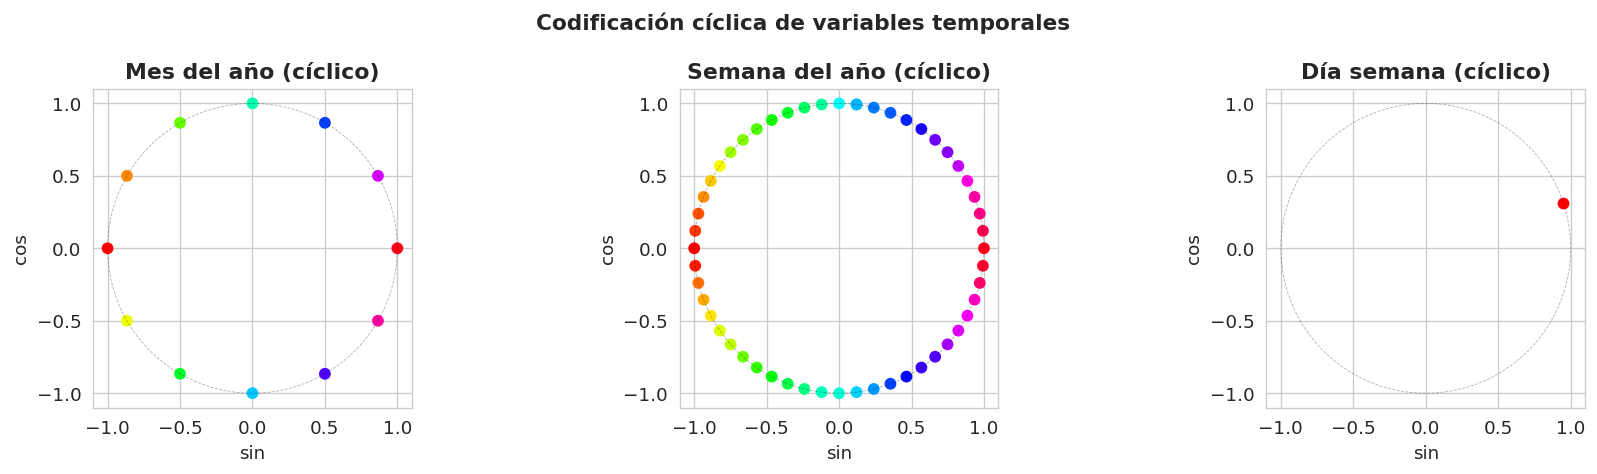

La codificación cíclica preserva la continuidad (e.g., semana 52 → semana 1).


In [55]:
# Visualización de la codificación cíclica vs lineal
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (var_sin, var_cos, titulo, n_ciclo) in zip(axes, [
    ('Mes_sin',    'Mes_cos',    'Mes del año (cíclico)',     12),
    ('Semana_sin', 'Semana_cos', 'Semana del año (cíclico)', 52),
    ('Dia_sin',    'Dia_cos',    'Día semana (cíclico)',       5),
]):
    sub = df_feat.drop_duplicates(subset=[var_sin, var_cos]).sort_values(var_sin)
    sc = ax.scatter(sub[var_sin], sub[var_cos], c=range(len(sub)), cmap='hsv', s=50, edgecolors='none')
    ax.set_xlabel('sin'); ax.set_ylabel('cos')
    ax.set_title(titulo, fontweight='bold')
    ax.set_aspect('equal')
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.sin(theta), np.cos(theta), 'k--', linewidth=0.5, alpha=0.3)

plt.suptitle('Codificación cíclica de variables temporales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('La codificación cíclica preserva la continuidad (e.g., semana 52 → semana 1).')

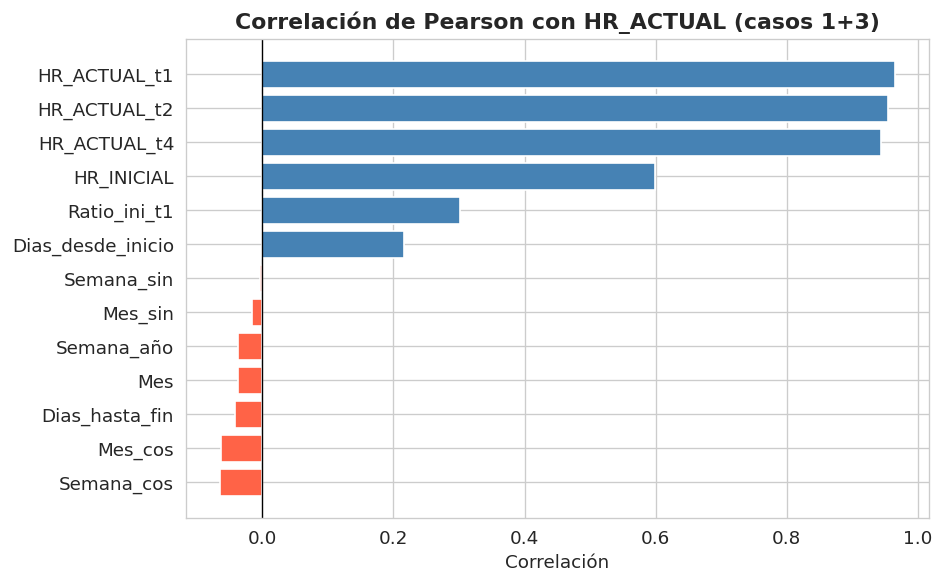

In [56]:
# Correlación de features con HR_ACTUAL
features_num = ['HR_ACTUAL_t1','HR_ACTUAL_t2','HR_ACTUAL_t4','HR_INICIAL',
                'Mes','Semana_año','Dias_desde_inicio','Dias_hasta_fin',
                'Mes_sin','Mes_cos','Semana_sin','Semana_cos','Ratio_ini_t1']

# Sólo casos 1 y 3
df_13 = df_feat[df_feat['Caso'].isin([1,3])].dropna(subset=features_num + ['HR_ACTUAL'])

corr = df_13[features_num + ['HR_ACTUAL']].corr()['HR_ACTUAL'].drop('HR_ACTUAL').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colores_corr = ['tomato' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colores_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Pearson con HR_ACTUAL (casos 1+3)', fontweight='bold')
ax.set_xlabel('Correlación')
plt.tight_layout()
plt.show()

In [57]:
# Guardar dataset procesado para siguientes fases (EN DRIVE)
ruta_guardado = f'{DATA_PATH}/ULAB_dataset_semanal_procesado.csv'

df_feat.to_csv(ruta_guardado, index=False)

print(f'Dataset guardado en: {ruta_guardado}')
print(f'Shape final: {df_feat.shape}')
print(f'Columnas: {list(df_feat.columns)}')

Dataset guardado en: /content/drive/MyDrive/Colab Notebooks/ULAB/data/ULAB_dataset_semanal_procesado.csv
Shape final: (8912, 23)
Columnas: ['Caso', 'Departamento', 'Semana_inicio', 'HR_ACTUAL', 'HR_INICIAL', 'Año', 'Mes', 'Semana_año', 'Dia_semana', 'Mes_sin', 'Mes_cos', 'Semana_sin', 'Semana_cos', 'Dia_sin', 'Dia_cos', 'Dias_desde_inicio', 'Dias_hasta_fin', 'Dias_hasta_fin_año', 'HR_ACTUAL_t1', 'HR_ACTUAL_t2', 'HR_ACTUAL_t4', 'HR_INI_t1', 'Ratio_ini_t1']


## 9. Análisis de muestreo no uniforme (días festivos)

El cronograma indica que el muestreo **no es uniforme** porque existen días festivos. Cuantificamos las semanas afectadas y evaluamos si el `fill_value=0` usado en la construcción de las series puede distorsionar la STL y el análisis espectral.

=== Impacto de días festivos / muestreo no uniforme ===


,Caso,Días esperados (L-V),Días con datos,Días faltantes,% faltantes,Semanas totales,Semanas con gap,% semanas con gap
0,1,912,1146,-234,-25.66,183,5,2.7
1,3,1034,1125,-91,-8.80,193,5,2.6


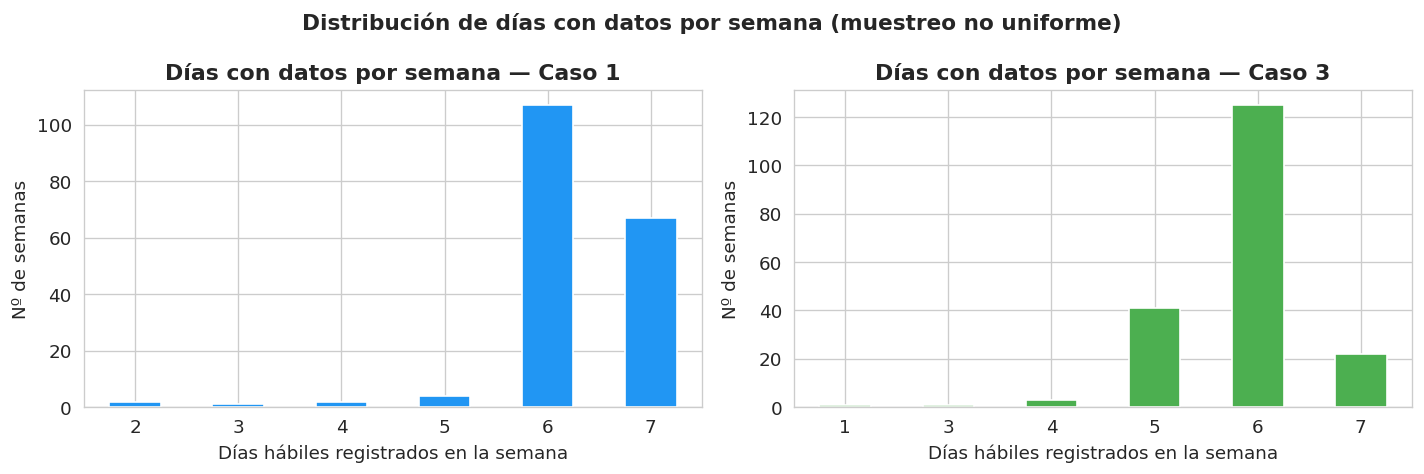

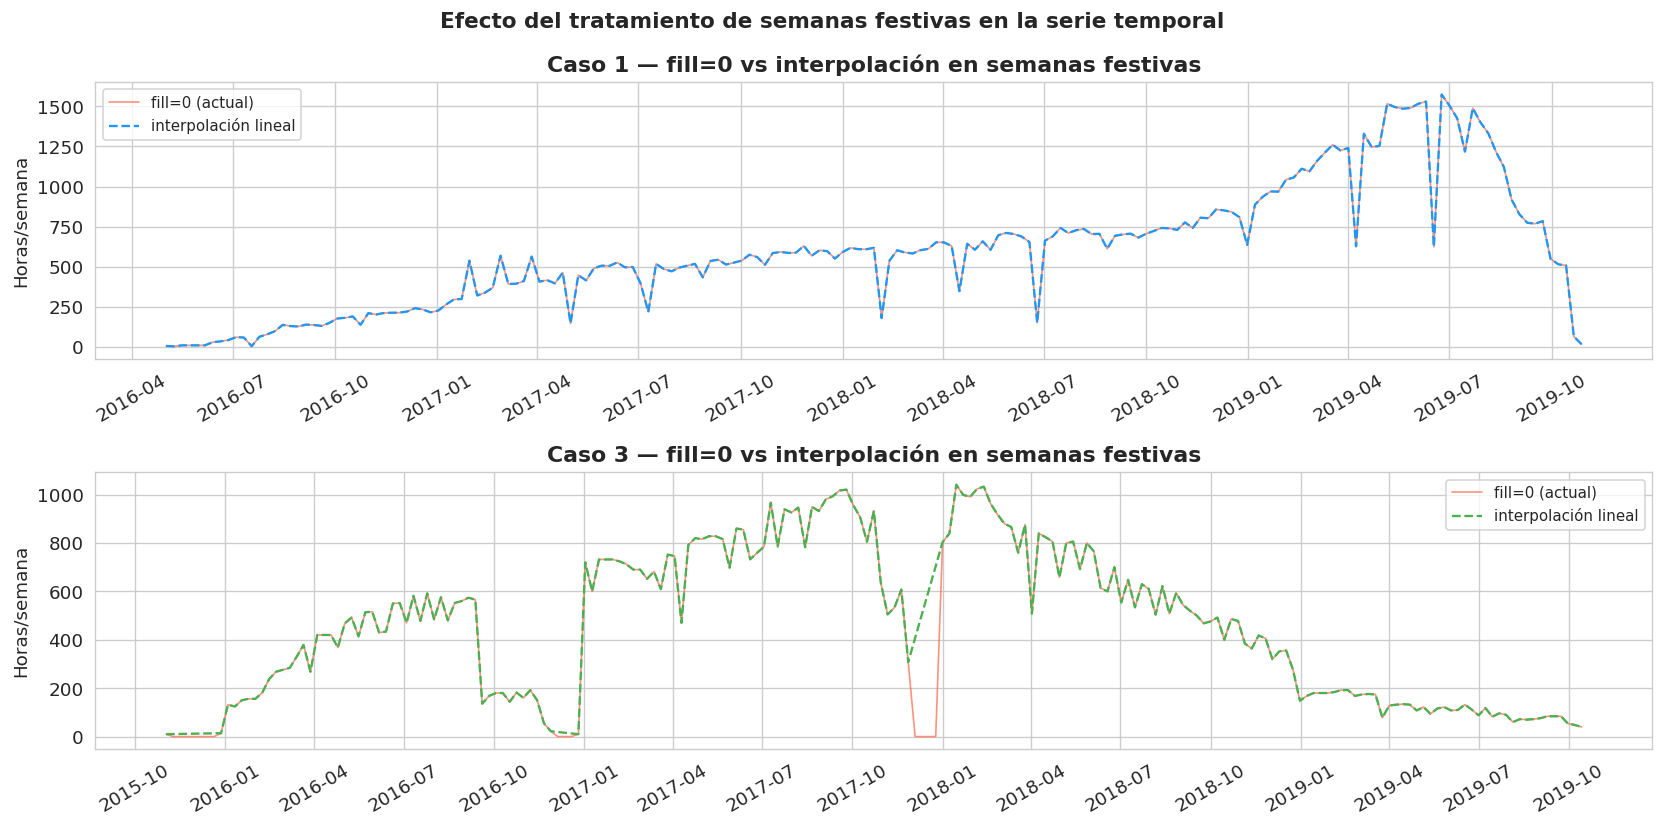


Conclusión: las semanas con < 5 días hábiles corresponden a semanas festivas.
El fill_value=0 introduce ceros artificiales que afectan a STL y al espectro.
Recomendación para modelado: usar interpolación lineal en gaps de 1-2 semanas.


In [58]:
# ── 9.1 Días hábiles esperados vs registrados ───────────────────────────────
resumen_gaps = []

for caso in [1, 3]:
    sub = df_act_clean[df_act_clean['Caso'] == caso].copy()
    rango = pd.date_range(sub['DIA'].min(), sub['DIA'].max(), freq='B')  # L-V
    dias_reales    = sub['DIA'].nunique()
    dias_esperados = len(rango)
    dias_faltantes = dias_esperados - dias_reales
    pct_faltantes  = 100 * dias_faltantes / dias_esperados

    sub['Semana_inicio'] = sub['DIA'] - pd.to_timedelta(sub['DIA'].dt.weekday, unit='d')
    semanas_con_datos = sub['Semana_inicio'].nunique()
    semanas_completas = sub.groupby('Semana_inicio')['DIA'].nunique()
    semanas_gap       = (semanas_completas < 5).sum()

    resumen_gaps.append({
        'Caso':                   caso,
        'Días esperados (L-V)':   dias_esperados,
        'Días con datos':         dias_reales,
        'Días faltantes':         dias_faltantes,
        '% faltantes':            round(pct_faltantes, 2),
        'Semanas totales':        semanas_con_datos,
        'Semanas con gap':        semanas_gap,
        '% semanas con gap':      round(100 * semanas_gap / semanas_con_datos, 1),
    })

df_gaps = pd.DataFrame(resumen_gaps)
print('=== Impacto de días festivos / muestreo no uniforme ===')
display(df_gaps)

# ── 9.2 Distribución de días-por-semana ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, caso, color in zip(axes, [1, 3], ['#2196F3', '#4CAF50']):
    sub = df_act_clean[df_act_clean['Caso'] == caso].copy()
    sub['Semana_inicio'] = sub['DIA'] - pd.to_timedelta(sub['DIA'].dt.weekday, unit='d')
    dias_x_semana = sub.groupby('Semana_inicio')['DIA'].nunique()
    dias_x_semana.value_counts().sort_index().plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Días con datos por semana — Caso {caso}', fontweight='bold')
    ax.set_xlabel('Días hábiles registrados en la semana')
    ax.set_ylabel('Nº de semanas')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.suptitle('Distribución de días con datos por semana (muestreo no uniforme)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 9.3 Comparar series con fill=0 vs interpolación lineal ───────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, caso, color in zip(axes, [1, 3], ['#2196F3', '#4CAF50']):
    sub = df_act_clean[df_act_clean['Caso'] == caso].copy()
    sub['Semana_inicio'] = sub['DIA'] - pd.to_timedelta(sub['DIA'].dt.weekday, unit='d')
    serie = sub.groupby('Semana_inicio')['HR ACTUAL'].sum().sort_index()
    idx_completo = pd.date_range(serie.index.min(), serie.index.max(), freq='W-MON')
    serie_fill0  = serie.reindex(idx_completo, fill_value=0)
    serie_interp = serie.reindex(idx_completo).interpolate(method='linear')

    ax.plot(serie_fill0.index,  serie_fill0.values,  color='tomato', linewidth=1,
            alpha=0.7, label='fill=0 (actual)')
    ax.plot(serie_interp.index, serie_interp.values, color=color, linewidth=1.4,
            linestyle='--', label='interpolación lineal')
    ax.set_title(f'Caso {caso} — fill=0 vs interpolación en semanas festivas', fontweight='bold')
    ax.set_ylabel('Horas/semana')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Efecto del tratamiento de semanas festivas en la serie temporal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nConclusión: las semanas con < 5 días hábiles corresponden a semanas festivas.')
print('El fill_value=0 introduce ceros artificiales que afectan a STL y al espectro.')
print('Recomendación para modelado: usar interpolación lineal en gaps de 1-2 semanas.')


## 10. Esquemas de validación cruzada

El cronograma especifica **tres esquemas** que se usarán de forma consistente en todas las fases del proyecto:

1. **Estratificado** — 80/20 aleatorio estratificado por caso + departamento
2. **Por casos** — entrenar en un caso, evaluar en el otro (y viceversa)
3. **Leave-one-dept-out** — dejar fuera un departamento entero como fold de evaluación

Se definen aquí las funciones y splits reutilizables para las Fases 2-4.

In [59]:
from sklearn.model_selection import train_test_split

# Dataset de referencia: casos 1 y 3, sin NaN en features clave
FEATURES_BASE = [
    'HR_ACTUAL_t1', 'HR_INICIAL', 'Mes', 'Semana_año',
    'Mes_sin', 'Mes_cos', 'Semana_sin', 'Semana_cos',
    'Dias_desde_inicio', 'Dias_hasta_fin', 'Departamento'
]
TARGET = 'HR_ACTUAL'

df_cv = df_feat[df_feat['Caso'].isin([1, 3])].dropna(
    subset=FEATURES_BASE + [TARGET]
).copy().reset_index(drop=True)

print(f'Dataset para CV: {df_cv.shape[0]:,} filas')
print(f'  Caso 1: {(df_cv.Caso==1).sum():,}   Caso 3: {(df_cv.Caso==3).sum():,}\n')

# ═══════════════════════════════════════════════════════════════════════════════
# ESQUEMA 1 — Estratificado por caso + departamento
# ═══════════════════════════════════════════════════════════════════════════════
df_cv['_estrato'] = df_cv['Caso'].astype(str) + '_' + df_cv['Departamento'].astype(str)

# Solo estratos con al menos 2 muestras (requisito de stratify)
estrato_counts  = df_cv['_estrato'].value_counts()
estratos_validos = estrato_counts[estrato_counts >= 2].index
df_cv_e1 = df_cv[df_cv['_estrato'].isin(estratos_validos)].copy()

X_e1 = df_cv_e1[FEATURES_BASE]
y_e1 = df_cv_e1[TARGET]

X_train_e1, X_test_e1, y_train_e1, y_test_e1 = train_test_split(
    X_e1, y_e1, test_size=0.2, random_state=42, stratify=df_cv_e1['_estrato']
)

print('ESQUEMA 1 — Estratificado por caso + departamento')
print(f'  Train: {len(X_train_e1):,}  |  Test: {len(X_test_e1):,}')
casos_train = df_cv_e1.loc[X_train_e1.index, 'Caso'].value_counts().to_dict()
casos_test  = df_cv_e1.loc[X_test_e1.index,  'Caso'].value_counts().to_dict()
print(f'  Casos en train: {casos_train}')
print(f'  Casos en test:  {casos_test}\n')

# ═══════════════════════════════════════════════════════════════════════════════
# ESQUEMA 2 — Por casos (cross-project)
# ═══════════════════════════════════════════════════════════════════════════════
mask_c1 = df_cv['Caso'] == 1
mask_c3 = df_cv['Caso'] == 3

# Split A: train en caso 1 → test en caso 3
X_train_c1 = df_cv.loc[mask_c1, FEATURES_BASE]
y_train_c1 = df_cv.loc[mask_c1, TARGET]
X_test_c3  = df_cv.loc[mask_c3, FEATURES_BASE]
y_test_c3  = df_cv.loc[mask_c3, TARGET]

# Split B: train en caso 3 → test en caso 1
X_train_c3 = df_cv.loc[mask_c3, FEATURES_BASE]
y_train_c3 = df_cv.loc[mask_c3, TARGET]
X_test_c1  = df_cv.loc[mask_c1, FEATURES_BASE]
y_test_c1  = df_cv.loc[mask_c1, TARGET]

print('ESQUEMA 2 — División por casos (cross-project generalization)')
print(f'  Split A — Train (caso 1): {len(X_train_c1):,}  |  Test (caso 3): {len(X_test_c3):,}')
print(f'  Split B — Train (caso 3): {len(X_train_c3):,}  |  Test (caso 1): {len(X_test_c1):,}\n')

# ═══════════════════════════════════════════════════════════════════════════════
# ESQUEMA 3 — Leave-one-dept-out
# ═══════════════════════════════════════════════════════════════════════════════
UMBRAL_MUESTRAS_DEPT = 30  # depts con < 30 semanas no se usan como fold de evaluación

muestras_por_dept = df_cv.groupby('Departamento').size()
depts_eval        = muestras_por_dept[muestras_por_dept >= UMBRAL_MUESTRAS_DEPT].index.tolist()

print(f'ESQUEMA 3 — Leave-one-dept-out')
print(f'  Departamentos totales con datos: {df_cv["Departamento"].nunique()}')
print(f'  Departamentos válidos para eval (>=>{UMBRAL_MUESTRAS_DEPT} muestras): {len(depts_eval)}')
print(f'  Total folds generables: {len(depts_eval)}\n')
print(f'  {"Dept eval":>12}  {"Train":>8}  {"Test":>8}')
print(f'  {"-"*12}  {"-"*8}  {"-"*8}')
for dept in depts_eval[:5]:
    mask_t = df_cv['Departamento'] == dept
    print(f'  {dept:>12}  {(~mask_t).sum():>8,}  {mask_t.sum():>8,}')
print(f'  ... ({len(depts_eval) - 5} folds más)\n')

# Guardar configuración para reutilizar en Fases 2-4
cv_config = {
    'features':        FEATURES_BASE,
    'target':          TARGET,
    'depts_eval': depts_eval,
    'depts_eval_lodo': depts_eval,  # alias de compatibilidad
    'umbral_lodo':     UMBRAL_MUESTRAS_DEPT,
    'random_state':    42,
    'test_size_e1':    0.2,
}
print('cv_config guardado — importar al inicio de los notebooks de fases 2-4.')
import joblib

cv_config_path = f'{MODELOS_PATH}/cv_config_fase1.pkl'
joblib.dump(cv_config, cv_config_path)

print(f'cv_config guardado en: {cv_config_path}')


Dataset para CV: 4,929 filas
  Caso 1: 3,055   Caso 3: 1,874

ESQUEMA 1 — Estratificado por caso + departamento
  Train: 3,943  |  Test: 986
  Casos en train: {1: 2444, 3: 1499}
  Casos en test:  {1: 611, 3: 375}

ESQUEMA 2 — División por casos (cross-project generalization)
  Split A — Train (caso 1): 3,055  |  Test (caso 3): 1,874
  Split B — Train (caso 3): 1,874  |  Test (caso 1): 3,055

ESQUEMA 3 — Leave-one-dept-out
  Departamentos totales con datos: 41
  Departamentos válidos para eval (>=>30 muestras): 34
  Total folds generables: 34

     Dept eval     Train      Test
  ------------  --------  --------
           100     4,811       118
           110     4,897        32
           140     4,841        88
           205     4,678       251
           350     4,827       102
  ... (29 folds más)

cv_config guardado — importar al inicio de los notebooks de fases 2-4.
cv_config guardado en: /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/cv_config_fase1.pkl


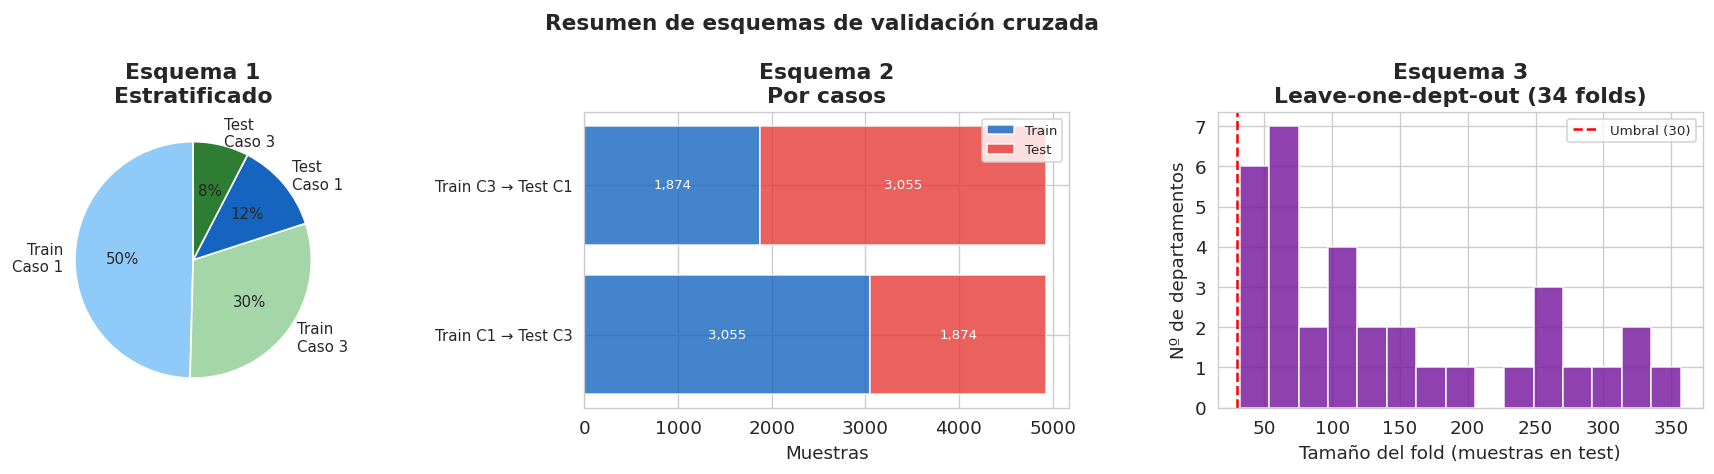


 Los tres esquemas de CV están listos para usarse en las Fases 2-4.
   Usar cv_config al inicio de cada notebook de modelado.


In [60]:
# Resumen visual de los tres esquemas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ─ Esquema 1: pastel train/test desglosado por caso ─
sizes_e1 = [
    (df_cv_e1.loc[X_train_e1.index, 'Caso'] == 1).sum(),
    (df_cv_e1.loc[X_train_e1.index, 'Caso'] == 3).sum(),
    (df_cv_e1.loc[X_test_e1.index,  'Caso'] == 1).sum(),
    (df_cv_e1.loc[X_test_e1.index,  'Caso'] == 3).sum(),
]
labels_e1 = ['Train\nCaso 1', 'Train\nCaso 3', 'Test\nCaso 1', 'Test\nCaso 3']
colors_e1 = ['#90CAF9', '#A5D6A7', '#1565C0', '#2E7D32']
axes[0].pie(sizes_e1, labels=labels_e1, colors=colors_e1, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 9})
axes[0].set_title('Esquema 1\nEstratificado', fontweight='bold')

# ─ Esquema 2: barras apiladas horizontales ─
splits_e2 = {
    'Train C1 → Test C3': [len(X_train_c1), len(X_test_c3)],
    'Train C3 → Test C1': [len(X_train_c3), len(X_test_c1)],
}
for i, (label, (tr, te)) in enumerate(splits_e2.items()):
    axes[1].barh(i, tr, color='#1565C0', alpha=0.8, label='Train' if i == 0 else '')
    axes[1].barh(i, te, left=tr, color='#E53935', alpha=0.8, label='Test' if i == 0 else '')
    axes[1].text(tr / 2,      i, f'{tr:,}', ha='center', va='center', fontsize=8, color='white')
    axes[1].text(tr + te / 2, i, f'{te:,}', ha='center', va='center', fontsize=8, color='white')
axes[1].set_yticks(range(len(splits_e2)))
axes[1].set_yticklabels(list(splits_e2.keys()), fontsize=9)
axes[1].set_xlabel('Muestras')
axes[1].set_title('Esquema 2\nPor casos', fontweight='bold')
axes[1].legend(fontsize=8)

# ─ Esquema 3: histograma tamaños de fold ─
fold_sizes = [(df_cv['Departamento'] == dept).sum() for dept in depts_eval]
axes[2].hist(fold_sizes, bins=15, color='#7B1FA2', edgecolor='white', alpha=0.85)
axes[2].axvline(UMBRAL_MUESTRAS_DEPT, color='red', linestyle='--',
                label=f'Umbral ({UMBRAL_MUESTRAS_DEPT})')
axes[2].set_title(f'Esquema 3\nLeave-one-dept-out ({len(depts_eval)} folds)',
                  fontweight='bold')
axes[2].set_xlabel('Tamaño del fold (muestras en test)')
axes[2].set_ylabel('Nº de departamentos')
axes[2].legend(fontsize=8)

plt.suptitle('Resumen de esquemas de validación cruzada', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Los tres esquemas de CV están listos para usarse en las Fases 2-4.')
print('   Usar cv_config al inicio de cada notebook de modelado.')


## 8. Conclusiones de la Fase 1

| Aspecto | Hallazgo |
|---|---|
| **Volumen** | 265,497 registros diarios (ACTUAL) · 15,041 (INICIAL) · 4 proyectos · 52 departamentos |
| **Proyectos de análisis** | Casos 1 (Turquía, +132%) y 3 (Colombia, +125%) — ambos finalizados |
| **Missing values** | 510 registros sin Departamento en ACTUAL (0.19%) → excluidos |
| **Outliers** | ~4.3% (IQR) a nivel diario; a nivel semanal agregado son menos críticos |
| **Periodicidad** | Periodicidades detectadas en el espectro (~13 y ~52 semanas) |
| **STL** | Fuerza tendencial alta en ambos casos (ciclo de vida del proyecto) |
| **Dataset final** | Nivel: semana × departamento × caso · Features: lags t-1/t-2/t-4, variables cíclicas/lineales, HR_INICIAL |

### Próximos pasos (Semanas 3-4)
- Modelos baseline: AR, ARIMA, SARIMA, Holt-Winters sobre series por departamento
- Modelos de regresión: Regresión lineal, Ridge/Lasso, SVR, K-NN, Random Forest, Gradient Boosting, AdaBoost
- Esquemas de validación cruzada: estratificada / por caso / leave-one-dept-out